In [1]:
import anndata
import muon as mu
import os
from pathlib import Path
import scanpy as sc
import scirpy as ir
import scvelo as scv
from tqdm import tqdm

/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [83]:
adata37 = sc.read_h5ad('../data/processed/BRI-2937.h5ad')
adata39 = sc.read_h5ad('../data/processed/BRI-2939.h5ad')
adata41 = sc.read_h5ad('../data/processed/BRI-2941.h5ad')

adata37.obs['condition'] = '2937'
adata39.obs['condition'] = '2939'
adata41.obs['condition'] = '2941'

adata = anndata.concat([adata37, adata39, adata41])

sample2Experiment = {k:f'BRI-{v}' for k,v in zip(adata.obs['sample'], adata.obs['condition'])}


adatas = []
for sample in tqdm(adata.obs['sample'].unique()):
    experiment = sample2Experiment[sample]
    experimentCountDir = Path(f'/home/tyj566/mnt/h/lsp-analysis/tyler/jasonSingleCell/{experiment}')

    adataSample = adata[adata.obs['sample'] == sample].copy()
    veloSubFolder = f'per_sample_outs/{sample}/count/velocyto'
    veloPath = experimentCountDir / veloSubFolder
    veloOut = veloPath / os.listdir(veloPath)[0]
    loomDat = sc.read(veloOut)
    loomDat.obs_names = [name.split(':')[-1].replace('x', '') for name in loomDat.obs_names]
    if '-' in adataSample.obs_names[0]:
        suffix = adataSample.obs_names[0].split('-')[-1]
        loomDat.obs_names = [f"{name}-{suffix}" for name in loomDat.obs_names]
    n_overlap = len(set(adataSample.obs_names).intersection(set(loomDat.obs_names)))
    print(f"Sample {sample}: {n_overlap} overlapping barcodes found.")
    adataSample.var_names_make_unique()
    adataSample = scv.utils.merge(adataSample, loomDat)
    
    adatas.append(adataSample)
adata = anndata.concat(adatas, join='outer')

  0%|          | 0/12 [00:00<?, ?it/s]

Sample 1: 873 overlapping barcodes found.


  8%|▊         | 1/12 [00:06<01:09,  6.35s/it]

Sample 2: 1383 overlapping barcodes found.


 17%|█▋        | 2/12 [00:17<01:31,  9.16s/it]

...

 83%|████████▎ | 10/12 [01:35<00:20, 10.29s/it]

Sample 10: 1767 overlapping barcodes found.


 92%|█████████▏| 11/12 [01:49<00:11, 11.55s/it]

Sample 12: 1401 overlapping barcodes found.


100%|██████████| 12/12 [02:00<00:00, 10.02s/it]


In [86]:
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [87]:
scv.pp.filter_and_normalize(adata)
scv.pp.moments(adata)
scv.tl.velocity(adata, mode='stochastic')
scv.tl.velocity_graph(adata)

computing neighbors


/tmp/ipykernel_1878825/614532018.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata)
/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:13) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:21) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


  0%|          | 0/15661 [00:00<?, ?cells/s]

/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py:960: DeprecationWarning: This process (pid=1878825) is multi-threaded, use of fork() may lead to deadlocks in the child.
  child_process = getattr(os, original_name)()  # fork


    finished (0:01:31) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [88]:
cellTypesT = ['NK cells',
'CD16- NK cells',
'Cycling NK cells',
'gamma-delta T cells',
'ILC3',
'Double-positive thymocytes',
'Tem/Trm cytotoxic T cells',
'Regulatory T cells']
adataT = adata[adata.obs['majority_voting_low'].isin(cellTypesT)].copy()
adataT.obs['Cd8Pos'] =   (adataT[:,'Cd8a'].X>0.2).todense()
adataT = adata[adata.obs['majority_voting_low'].isin(cellTypesT)]

adataT.obs['Cd8Pos'] =   (adataT[:,'Cd8a'].X>0.2).todense()
adataCd8 = adataT[adataT.obs['Cd8Pos']]
sc.pp.normalize_per_cell(adataCd8)
sc.pp.log1p(adataCd8)
# sc.pp.highly_variable_genes(adataCd8, flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(adataCd8)
sc.pp.neighbors(adataCd8)
sc.tl.umap(adataCd8)

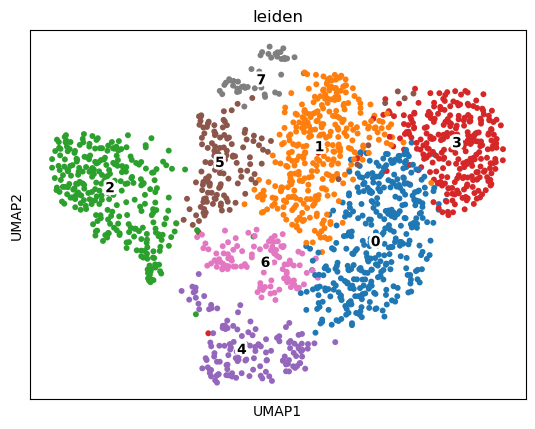

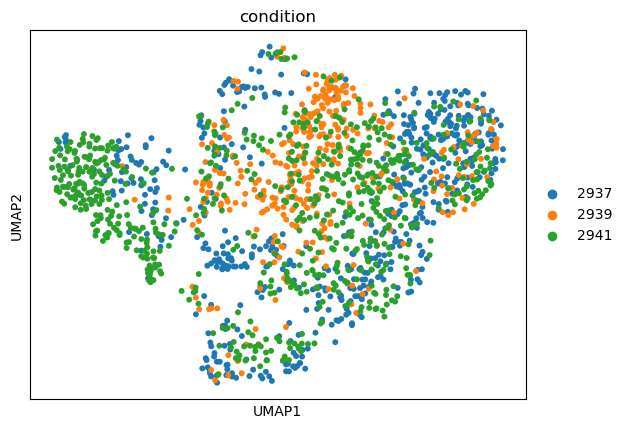

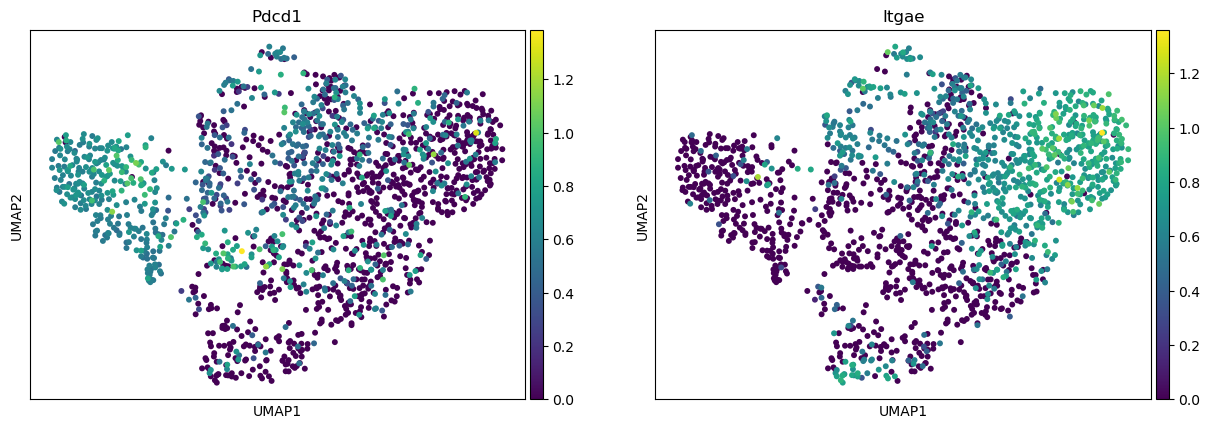

In [90]:
sc.tl.leiden(adataCd8, resolution=.5, random_state=1234)
sc.pl.umap(adataCd8, color='leiden',add_outline=False,legend_loc="on data", legend_fontoutline=4)
sc.pl.umap(adataCd8, color='condition')
sc.pl.umap(adataCd8, color=['Pdcd1', 'Itgae'], wspace=0.15)

In [91]:
scv.tl.velocity_graph(adataCd8)

computing velocity graph (using 1/24 cores)


  0%|          | 0/1647 [00:00<?, ?cells/s]

/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py:960: DeprecationWarning: This process (pid=1878825) is multi-threaded, use of fork() may lead to deadlocks in the child.
  child_process = getattr(os, original_name)()  # fork


    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


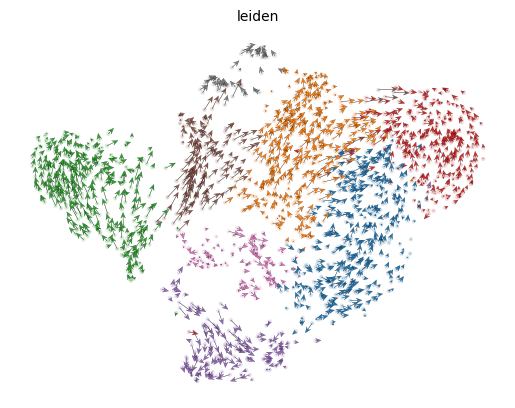

In [92]:
scv.pl.velocity_embedding(
    adataCd8,
    basis='umap',
    arrow_length=3,
    arrow_size=2,
    color='leiden'
)

In [93]:
adata37 = sc.read_h5ad('../data/processed/BRI-2937_tcr.h5ad')
adata39 = sc.read_h5ad('../data/processed/BRI-2939_tcr.h5ad')
adata41 = sc.read_h5ad('../data/processed/BRI-2941_tcr.h5ad')

adata37.obs['condition'] = '2937'
adata39.obs['condition'] = '2939'
adata41.obs['condition'] = '2941'

adata_tcr = anndata.concat([adata37, adata39, adata41])

In [94]:
adataCd8

AnnData object with n_obs × n_vars = 1647 × 18420
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'majority_voting_low', 'conf_score_low', 'majority_voting_high', 'conf_score_high', 'condition', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'n_genes', 'velocity_self_transition', 'Cd8Pos', 'leiden'
    var: 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'neighbors', 'velocity_params', 'log1p', 'hvg', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'leiden'

In [95]:
adataCd8.obs_names = adataCd8.obs_names.str.replace(r'-\d+$', '', regex=True)
adata_tcr.obs_names = adata_tcr.obs_names.str.replace(r'-\d+$', '', regex=True)

adata_tcr.obs_names_make_unique()
adataCd8.obs_names_make_unique()
mdata = mu.MuData({"gex": adataCd8, "airr": adata_tcr})

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
)
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")
ir.tl.clonal_expansion(mdata)

/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/scirpy/tl/_clonotypes.py:320: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  part = g.clusters(mode="weak")
/data/trm-sc-analysis/.pixi/envs/default/lib/python3.12/site-packages/scirpy/tl/_clonotypes.py:320: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  part = g.clusters(mode="weak")


In [96]:
mdata

MuData object with n_obs × n_vars = 4567 × 18420
  2 modalities
    gex:	1647 x 18420
      obs:	'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'majority_voting_low', 'conf_score_low', 'majority_voting_high', 'conf_score_high', 'condition', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'n_genes', 'velocity_self_transition', 'Cd8Pos', 'leiden'
      var:	'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'neighbors', 'velocity_params', 'log1p', 'hvg', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'leiden', 'leiden_colors', 'condition_colors'
      obsm:	'X_pca', 'X_umap', 'velocity_umap'
      varm:	'PCs'
      layers:	'counts', 'log1p_norm', 'matrix', 'ambiguous', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
      obsp:	'distances', 'connectivities'
    airr:	4444 x 0
      obs:	'condition', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices'

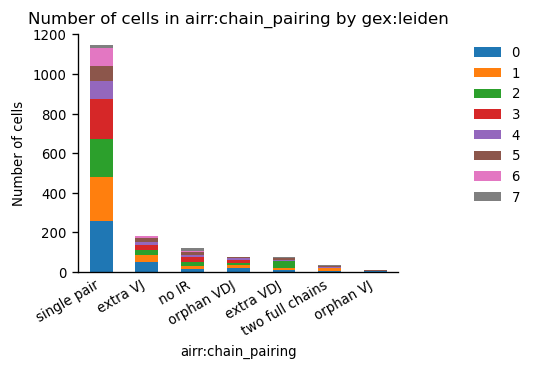

In [97]:
ax = ir.pl.group_abundance(mdata, groupby="airr:chain_pairing", target_col="gex:leiden")

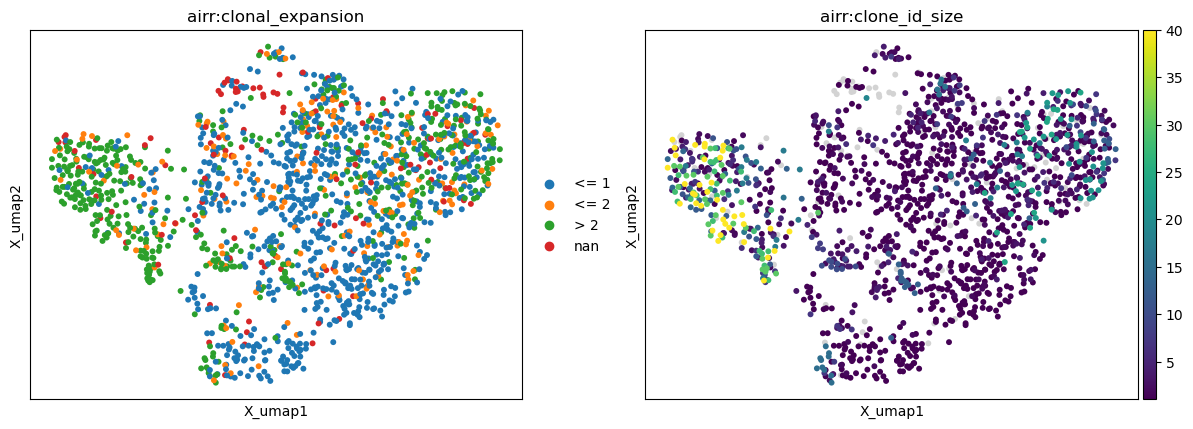

In [98]:
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:clonal_expansion", "airr:clone_id_size"])

In [99]:
sc.tl.rank_genes_groups(adataCd8, 'leiden', method='wilcoxon')

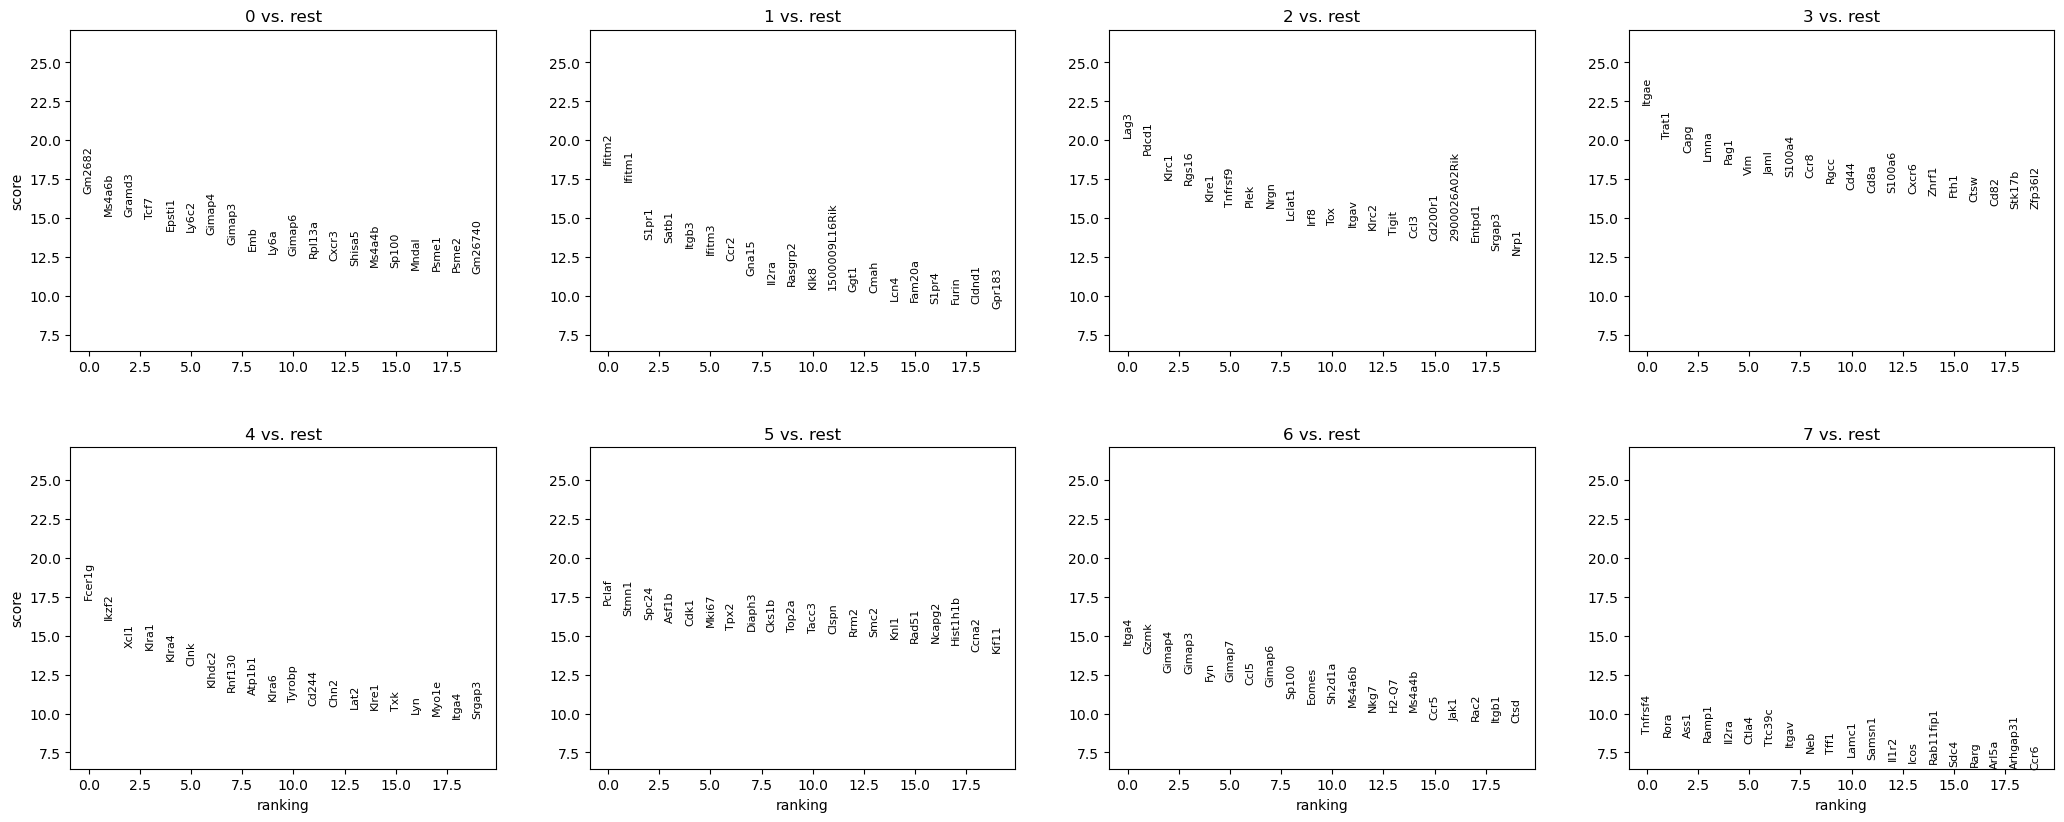

In [100]:
sc.pl.rank_genes_groups(adataCd8)